In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional
from tensorflow.keras.layers import Input, Concatenate, Flatten
from tensorflow.keras.utils import to_categorical

In [ ]:
import os
os.listdir()

['.config', 'sample_data']

In [ ]:
!pip install -q gdown

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/13yutFbDlIkaEK_5s6yue8yDGISupYpbi

Retrieving folder contents
Retrieving folder 1qef0GuEb9b4gFEErkvRBYftNrha1sTkn 2D skeleton
Processing file 121RGDCOfTpxM3dvfeMCWjmqW4YyvowJq 2D_openpose.zip
Processing file 1UwpwGGY0GfXh-d0cUOAPLE3x9L0inicq ROMP_2D_Coordinates.zip
Retrieving folder 1fekH0D7OR7aTT39t8DPRBReYyJ_kgMdp 3D skeleton
Processing file 1u0QOAiLELnfCToY1pbaNSPyrLvWMUAWb ROMP_3D_Coordinates_71-joints.zip
Processing file 1LY7ZNIodIOmnKzHxjrtGp7g-eG3A0p2O ROMP_3D_Coordinates.zip
Processing file 1-dOw8QYkEYGqiJ9MCicyjmGTPMF3LDLD ADOS_rating.xlsx
Processing file 16xMJvaPsLctPsyt9OX7WK8361Wo6pQqN optical_flow.zip
Processing file 1FnstDV-7B8sn9sr-LJYx4JHOqZgAVf0U README.txt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=121RGDCOfTpxM3dvfeMCWjmqW4YyvowJq
From (redirected): https://drive.google.com/uc?id=121RGDCOfTpxM3dvfeMCWjmqW4YyvowJq&confirm=t&uuid=6d3807c1-c12e-41ff-a69a-23c4821533b8
To: /content/D

In [ ]:
import os
os.listdir()

['.config', 'Dataset_FINAL', 'sample_data']

In [ ]:
import os

print(os.listdir("Dataset_FINAL"))

['optical_flow.zip', 'README.txt', '3D skeleton', 'ADOS_rating.xlsx', '2D skeleton']


In [ ]:
import pandas as pd

clinical = pd.read_excel("Dataset_FINAL/ADOS_rating.xlsx")
clinical.head()

,ID#,Gender,Chronological Age,Module,Social Affect Total,Restricted and Repetitive Behavior (RRB) Total,Overall Total,ADOS-2 classification/Dx,"ADOS Comparison Score (1-10) <5 not very autistic. ASD people usually fall 5-10. 8-10=Severe, 5-7=moderate, 1-4=mild",Severity of Autism
0,20274,M,"6Y,9M",2,18.0,3.0,21.0,2,9,3
1,20313,M,9y,2,19.0,5.0,24.0,2,10,3
2,20383,M,"5Y,8M",3,19.0,3.0,22.0,2,10,3
3,20453,M,"7Y,4M",3,5.0,3.0,8.0,1,8,3
4,20564,M,"6Y,8M",2,15.0,4.0,19.0,2,8,3


In [ ]:
for root, dirs, files in os.walk("Dataset_FINAL"):
    print(root)
    print(files[:5])

Dataset_FINAL
['optical_flow.zip', 'README.txt', 'ADOS_rating.xlsx']
Dataset_FINAL/3D skeleton
['ROMP_3D_Coordinates_71-joints.zip', 'ROMP_3D_Coordinates.zip']
Dataset_FINAL/2D skeleton
['ROMP_2D_Coordinates.zip', '2D_openpose.zip']


In [ ]:
print(os.listdir("Dataset_FINAL"))

['optical_flow.zip', 'README.txt', '3D skeleton', 'ADOS_rating.xlsx', '2D skeleton']


In [ ]:
import pandas as pd

clinical = pd.read_excel("Dataset_FINAL/ADOS_rating.xlsx")
clinical.head()

,ID#,Gender,Chronological Age,Module,Social Affect Total,Restricted and Repetitive Behavior (RRB) Total,Overall Total,ADOS-2 classification/Dx,"ADOS Comparison Score (1-10) <5 not very autistic. ASD people usually fall 5-10. 8-10=Severe, 5-7=moderate, 1-4=mild",Severity of Autism
0,20274,M,"6Y,9M",2,18.0,3.0,21.0,2,9,3
1,20313,M,9y,2,19.0,5.0,24.0,2,10,3
2,20383,M,"5Y,8M",3,19.0,3.0,22.0,2,10,3
3,20453,M,"7Y,4M",3,5.0,3.0,8.0,1,8,3
4,20564,M,"6Y,8M",2,15.0,4.0,19.0,2,8,3


In [ ]:
import zipfile

with zipfile.ZipFile("Dataset_FINAL/optical_flow.zip", 'r') as zip_ref:
    zip_ref.extractall("Dataset_FINAL/optical_flow")

In [ ]:
import os
print(os.listdir("Dataset_FINAL/optical_flow")[:10])

['optical_flow_jpg']


In [ ]:
import os

print("3D Skeleton Files:")
print(os.listdir("Dataset_FINAL/3D skeleton")[:10])

print("\n2D Skeleton Files:")
print(os.listdir("Dataset_FINAL/2D skeleton")[:10])

3D Skeleton Files:
['ROMP_3D_Coordinates_71-joints.zip', 'ROMP_3D_Coordinates.zip']

2D Skeleton Files:
['ROMP_2D_Coordinates.zip', '2D_openpose.zip']


In [ ]:
import pandas as pd

clinical = pd.read_excel("Dataset_FINAL/ADOS_rating.xlsx")
print(clinical.columns)

Index(['ID#', 'Gender', 'Chronological Age', 'Module', 'Social Affect Total ',
       'Restricted and Repetitive Behavior (RRB) Total', 'Overall Total ',
       'ADOS-2 classification/Dx',
       'ADOS Comparison Score (1-10) <5  not very autistic. ASD people usually fall 5-10. 8-10=Severe, 5-7=moderate, 1-4=mild',
       'Severity of Autism  '],
      dtype='object')


In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical

In [ ]:
with zipfile.ZipFile("Dataset_FINAL/3D skeleton/ROMP_3D_Coordinates.zip",'r') as zip_ref:
    zip_ref.extractall("Dataset_FINAL/3D_extracted")

In [ ]:
clinical = pd.read_excel("Dataset_FINAL/ADOS_rating.xlsx")
clinical.head()

,ID#,Gender,Chronological Age,Module,Social Affect Total,Restricted and Repetitive Behavior (RRB) Total,Overall Total,ADOS-2 classification/Dx,"ADOS Comparison Score (1-10) <5 not very autistic. ASD people usually fall 5-10. 8-10=Severe, 5-7=moderate, 1-4=mild",Severity of Autism
0,20274,M,"6Y,9M",2,18.0,3.0,21.0,2,9,3
1,20313,M,9y,2,19.0,5.0,24.0,2,10,3
2,20383,M,"5Y,8M",3,19.0,3.0,22.0,2,10,3
3,20453,M,"7Y,4M",3,5.0,3.0,8.0,1,8,3
4,20564,M,"6Y,8M",2,15.0,4.0,19.0,2,8,3


In [ ]:
os.listdir("Dataset_FINAL/3D_extracted")[:10]

['drumming_dr',
 'maracas_shaking_ms',
 'body_swing_bs',
 'arm_swing_as',
 'tree_pose_tr',
 'squat_sq',
 'maracas_forward_shaking_mfs',
 'frog_pose_fg',
 'chest_expansion_ce',
 'twist_pose_tw']

In [ ]:
def load_npz(file):
    data = np.load(file)
    return data[list(data.keys())[0]]

In [ ]:
X = []
y = []

folder = "Dataset_FINAL/3D_extracted"

for file in os.listdir(folder):
    if file.endswith(".npz"):
        arr = load_npz(os.path.join(folder,file))

        # Flatten joints
        arr = arr.reshape(arr.shape[0], -1)

        # pad/truncate
        max_frames = 100
        features = arr.shape[1]

        if len(arr) > max_frames:
            arr = arr[:100]
        else:
            pad = np.zeros((100-len(arr), features))
            arr = np.vstack([arr,pad])

        X.append(arr)

        # example label random until ID match
        y.append("Moderate")

In [ ]:
X = np.array(X)

le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)


ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
import os

for root, dirs, files in os.walk("Dataset_FINAL/3D_extracted"):
    print("FOLDER:", root)
    print("FILES:", files[:5])
    print("------")


Streaming output truncated to the last 5000 lines.
FILES: ['00000021.npz', '00000042.npz', '00000041.npz', '00000158.npz', '00000008.npz']
------
FOLDER: Dataset_FINAL/3D_extracted/drumming_dr/dr_40493_D16_003_i
FILES: ['00000021.npz', '00000042.npz', '00000041.npz', '00000008.npz', '00000009.npz']
------
FOLDER: Dataset_FINAL/3D_extracted/drumming_dr/dr_40543_D16_008_y
FILES: ['00000021.npz', '00000042.npz', '00000041.npz', '00000158.npz', '00000008.npz']
------
FOLDER: Dataset_FINAL/3D_extracted/drumming_dr/dr_40143_D1_008_y
FILES: ['00000021.npz', '00000042.npz', '00000041.npz', '00000158.npz', '00000008.npz']
------
FOLDER: Dataset_FINAL/3D_extracted/drumming_dr/dr_40453_D1_004_i
FILES: ['00000021.npz', '00000042.npz', '00000041.npz', '00000008.npz', '00000009.npz']
------
FOLDER: Dataset_FINAL/3D_extracted/drumming_dr/dr_40493_D1_006_n
FILES: ['00000021.npz', '00000042.npz', '00000041.npz', '00000008.npz', '00000009.npz']
------
FOLDER: Dataset_FINAL/3D_extracted/drumming_dr/dr_40

In [ ]:
import os
import numpy as np

X = []
y = []

base = "Dataset_FINAL/3D_extracted"

max_frames = 100

for activity in os.listdir(base):

    activity_path = os.path.join(base, activity)

    if os.path.isdir(activity_path):

        for sample in os.listdir(activity_path):

            sample_path = os.path.join(activity_path, sample)

            if os.path.isdir(sample_path):

                frames = []

                files = sorted(os.listdir(sample_path))

                for f in files:
                    if f.endswith(".npz"):

                        arr = np.load(os.path.join(sample_path,f))
                        data = arr[list(arr.keys())[0]]

                        flat = data.flatten()
                        frames.append(flat)

                if len(frames) == 0:
                    continue

                frames = np.array(frames)

                feature_size = frames.shape[1]

                # pad/truncate
                if len(frames) > max_frames:
                    frames = frames[:max_frames]
                else:
                    pad = np.zeros((max_frames-len(frames), feature_size))
                    frames = np.vstack([frames,pad])

                X.append(frames)
                y.append(activity)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (150,) + inhomogeneous part.

In [ ]:
import os
import numpy as np

X = []
y = []

base = "Dataset_FINAL/3D_extracted"
max_frames = 100
fixed_features = 213   # 71 joints × 3 coords

for activity in os.listdir(base):

    activity_path = os.path.join(base, activity)

    if os.path.isdir(activity_path):

        for sample in os.listdir(activity_path):

            sample_path = os.path.join(activity_path, sample)

            if os.path.isdir(sample_path):

                frames = []

                files = sorted(os.listdir(sample_path))

                for f in files:
                    if f.endswith(".npz"):

                        data = np.load(os.path.join(sample_path,f))
                        arr = data[list(data.keys())[0]]

                        flat = arr.flatten()

                        # fix feature length
                        if len(flat) > fixed_features:
                            flat = flat[:fixed_features]
                        else:
                            pad = np.zeros(fixed_features - len(flat))
                            flat = np.concatenate([flat, pad])

                        frames.append(flat)

                if len(frames) == 0:
                    continue

                frames = np.array(frames)

                # fix frame count
                if len(frames) > max_frames:
                    frames = frames[:max_frames]
                else:
                    pad = np.zeros((max_frames-len(frames), fixed_features))
                    frames = np.vstack([frames,pad])

                X.append(frames)
                y.append(activity)

In [ ]:
X = np.array(X)

print(X.shape)
print(len(y))
print(set(y))

(1693, 100, 213)
1693
{'chest_expansion_ce', 'tree_pose_tr', 'body_swing_bs', 'sing_and_clap_sac', 'maracas_shaking_ms', 'frog_pose_fg', 'twist_pose_tw', 'squat_sq', 'arm_swing_as', 'maracas_forward_shaking_mfs', 'drumming_dr'}


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

print(y_cat.shape)


ValueError: y should be a 1d array, got an array of shape (1693, 11) instead.

In [ ]:
print(y.shape)
y_cat = y

(1693, 11)


In [ ]:
y_encoded = np.argmax(y, axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

y_encoded = np.argmax(y_cat, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape, X_test.shape)

(1354, 100, 213) (339, 100, 213)


In [ ]:
X_train.shape

(1354, 100, 213)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

model = Sequential()

model.add(
    Bidirectional(
        LSTM(64, return_sequences=True),
        input_shape=(100,213)
    )
)

model.add(Dropout(0.3))

model.add(
    Bidirectional(
        LSTM(32)
    )
)

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(11, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │       142,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,427 (736.04 KB)

 Trainable params: 188,427 (736.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16
)

Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 188ms/step - accuracy: 0.4254 - loss: 1.6442 - val_accuracy: 0.3835 - val_loss: 1.8946
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 0.4069 - loss: 1.6209 - val_accuracy: 0.3864 - val_loss: 1.6388
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.3737 - loss: 1.6741 - val_accuracy: 0.3894 - val_loss: 1.6420
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.4202 - loss: 1.5693 - val_accuracy: 0.4159 - val_loss: 1.6400
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.3944 - loss: 1.6567 - val_accuracy: 0.4130 - val_loss: 1.6341
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.4372 - loss: 1.5740 - val_accuracy: 0.4100 - val_loss: 1.6483
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.3796 - loss: 1.6781 - val_accuracy: 0.3894 - val_loss: 1.6551
Epoch 8/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.4092 - loss: 1.5727 - val_accur

In [ ]:
import zipfile

with zipfile.ZipFile("Dataset_FINAL/2D skeleton/ROMP_2D_Coordinates.zip",'r') as zip_ref:
    zip_ref.extractall("Dataset_FINAL/2D_extracted")

In [ ]:
import os
for root, dirs, files in os.walk("Dataset_FINAL/2D_extracted"):
    print(root, files[:3])
    break

Dataset_FINAL/2D_extracted []


In [ ]:
import os

for root, dirs, files in os.walk("Dataset_FINAL/2D_extracted"):
    print("FOLDER:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("------")

Streaming output truncated to the last 5000 lines.
FOLDER: Dataset_FINAL/2D_extracted/drumming_dr/dr_40493_D8_014_i
DIRS: []
FILES: ['00000021.npz', '00000042.npz', '00000041.npz', '00000008.npz', '00000127.npz']
------
FOLDER: Dataset_FINAL/2D_extracted/drumming_dr/dr_40023_D16_012_i
DIRS: []
FILES: ['00000220.npz', '00000021.npz', '00000042.npz', '00000041.npz', '00000158.npz']
------
FOLDER: Dataset_FINAL/2D_extracted/drumming_dr/dr_20564_D8_000_y
DIRS: []
FILES: ['00000249.npz', '00000220.npz', '00000021.npz', '00000042.npz', '00000268.npz']
------
FOLDER: Dataset_FINAL/2D_extracted/drumming_dr/dr_40023_D1_010_i
DIRS: []
FILES: ['00000021.npz', '00000042.npz', '00000041.npz', '00000008.npz', '00000127.npz']
------
FOLDER: Dataset_FINAL/2D_extracted/drumming_dr/dr_20583_D16_002_i
DIRS: []
FILES: ['00000249.npz', '00000220.npz', '00000021.npz', '00000042.npz', '00000268.npz']
------
FOLDER: Dataset_FINAL/2D_extracted/drumming_dr/dr_40555_D16_003_n
DIRS: []
FILES: ['00000021.npz', '00

In [ ]:
import os
import numpy as np

X2 = []
y2 = []

base = "Dataset_FINAL/2D_extracted"

max_frames = 100
fixed_features = 142

for activity in os.listdir(base):

    activity_path = os.path.join(base, activity)

    if os.path.isdir(activity_path):

        for sample in os.listdir(activity_path):

            sample_path = os.path.join(activity_path, sample)

            if os.path.isdir(sample_path):

                frames = []

                for f in sorted(os.listdir(sample_path)):

                    if f.endswith(".npz"):

                        data = np.load(os.path.join(sample_path,f))
                        arr = data[list(data.keys())[0]]

                        flat = arr.flatten()

                        if len(flat) > fixed_features:
                            flat = flat[:fixed_features]
                        else:
                            pad = np.zeros(fixed_features-len(flat))
                            flat = np.concatenate([flat,pad])

                        frames.append(flat)

                if len(frames) == 0:
                    continue

                frames = np.array(frames)

                if len(frames) > max_frames:
                    frames = frames[:max_frames]
                else:
                    pad = np.zeros((max_frames-len(frames), fixed_features))
                    frames = np.vstack([frames,pad])

                X2.append(frames)
                y2.append(activity)

In [ ]:
X2 = np.array(X2)

print(X2.shape)
print(len(y2))
print(set(y2))

(1693, 100, 142)
1693
{'chest_expansion_ce', 'tree_pose_tr', 'body_swing_bs', 'sing_and_clap_sac', 'maracas_shaking_ms', 'frog_pose_fg', 'twist_pose_tw', 'squat_sq', 'arm_swing_as', 'maracas_forward_shaking_mfs', 'drumming_dr'}


In [ ]:
print(X2.shape)
print(len(y2))

(1693, 100, 142)
1693


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

labels = y2   # same labels
y_enc = le.fit_transform(labels)
y_cat = to_categorical(y_enc)

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

idx = np.arange(len(X))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y_cat, axis=1)
)

X3_train = X[train_idx]
X3_test  = X[test_idx]

X2_train = X2[train_idx]
X2_test  = X2[test_idx]

y_train = y_cat[train_idx]
y_test  = y_cat[test_idx]

print(X3_train.shape, X2_train.shape)

(1354, 100, 213) (1354, 100, 142)


In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import GRU, Bidirectional
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model

In [ ]:
# 3D branch
input3d = Input(shape=(100,213))

a = Bidirectional(GRU(64))(input3d)


# 2D branch
input2d = Input(shape=(100,142))

b = Bidirectional(GRU(64))(input2d)


# Fusion
merged = Concatenate()([a,b])

x = Dense(128, activation='relu')(merged)
x = Dropout(0.3)(x)

output = Dense(11, activation='softmax')(x)

model = Model(inputs=[input3d,input2d], outputs=output)

model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 100, 213)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 100, 142)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 128)       │    107,136 │ input_layer_3[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 128)       │     79,872 │ input_layer_4[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ bidirectional_6[… │
│ (Concatenate)       │                   │            │ bidirectional_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 11)        │      1,419 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 221,323 (864.54 KB)

 Trainable params: 221,323 (864.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    [X3_train, X2_train],
    y_train,
    validation_data=([X3_test, X2_test], y_test),
    epochs=30,
    batch_size=16
)

Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 17s 129ms/step - accuracy: 0.4003 - loss: 1.7909 - val_accuracy: 0.5162 - val_loss: 1.3436
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.5761 - loss: 1.2304 - val_accuracy: 0.6460 - val_loss: 1.0619
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step - accuracy: 0.6477 - loss: 0.9289 - val_accuracy: 0.6814 - val_loss: 0.8422
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.7194 - loss: 0.7239 - val_accuracy: 0.6903 - val_loss: 0.7282
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step - accuracy: 0.7437 - loss: 0.6437 - val_accuracy: 0.7139 - val_loss: 0.6608
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.7814 - loss: 0.5337 - val_accuracy: 0.7198 - val_loss: 0.6205
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.8065 - loss: 0.4855 - val_accuracy: 0.7434 - val_loss: 0.6502
Epoch 8/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.8383 - loss: 0.4090 - val_accu

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

In [ ]:
loss, acc = model.evaluate([X3_test, X2_test], y_test)
print("Test Accuracy:", acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.8201 - loss: 0.6722
Test Accuracy: 0.8200590014457703


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict([X3_test, X2_test])
pred_labels = np.argmax(pred, axis=1)
true_labels = np.argmax(y_test, axis=1)

print(classification_report(true_labels, pred_labels))

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 289ms/step
              precision    recall  f1-score   support

           0       0.86      0.57      0.69        21
           1       0.76      0.79      0.78        24
           2       0.57      0.74      0.64        23
           3       0.96      0.93      0.94       109
           4       0.85      0.96      0.90        23
           5       0.56      0.50      0.53        20
           6       0.62      0.69      0.65        26
           7       0.77      0.74      0.76        23
           8       0.81      0.65      0.72        20
           9       0.89      0.96      0.93        26
          10       0.92      1.00      0.96        24

    accuracy                           0.82       339
   macro avg       0.78      0.78      0.77       339
weighted avg       0.83      0.82      0.82       339



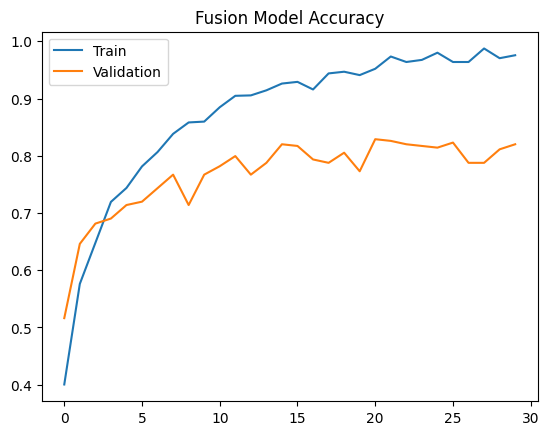

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Fusion Model Accuracy")
plt.show()

In [ ]:
import os

for root, dirs, files in os.walk("Dataset_FINAL/optical_flow/optical_flow_jpg"):
    print("FOLDER:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("------")
    break

FOLDER: Dataset_FINAL/optical_flow/optical_flow_jpg
DIRS: ['drumming_dr', 'maracas_shaking_ms', 'body_swing_bs', 'arm_swing_as', 'tree_pose_tr']
FILES: []
------


In [ ]:
import cv2
import numpy as np
import os

Xflow = []

base = "Dataset_FINAL/optical_flow/optical_flow_jpg"

img_size = 128

for activity in sorted(os.listdir(base)):

    activity_path = os.path.join(base, activity)

    if os.path.isdir(activity_path):

        for sample in sorted(os.listdir(activity_path)):

            sample_path = os.path.join(activity_path, sample)

            if os.path.isdir(sample_path):

                imgs = [f for f in os.listdir(sample_path)
                        if f.lower().endswith((".jpg",".png",".jpeg"))]

                if len(imgs) == 0:
                    img = np.zeros((img_size,img_size,3))
                else:
                    first_img = os.path.join(sample_path, imgs[0])
                    img = cv2.imread(first_img)
                    img = cv2.resize(img, (img_size,img_size))
                    img = img / 255.0

                Xflow.append(img)

In [ ]:
Xflow = np.array(Xflow)

print(Xflow.shape)

(1310, 128, 128, 3)


In [ ]:
n = min(len(X), len(X2), len(Xflow), len(y_cat))

print("Common samples:", n)

X3_final = X[:n]
X2_final = X2[:n]
Xflow_final = Xflow[:n]
y_final = y_cat[:n]

Common samples: 1310


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

idx = np.arange(n)

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y_final, axis=1)
)

X3_train = X3_final[train_idx]
X3_test  = X3_final[test_idx]

X2_train = X2_final[train_idx]
X2_test  = X2_final[test_idx]

Xflow_train = Xflow_final[train_idx]
Xflow_test  = Xflow_final[test_idx]

y_train = y_final[train_idx]
y_test  = y_final[test_idx]

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import GRU, Bidirectional
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model

In [ ]:
# 3D branch
input3d = Input(shape=(100,213))

a = Bidirectional(GRU(64))(input3d)


# 2D branch
input2d = Input(shape=(100,142))

b = Bidirectional(GRU(64))(input2d)


# Optical Flow branch
inputflow = Input(shape=(128,128,3))

c = Conv2D(32,(3,3), activation='relu')(inputflow)
c = MaxPooling2D()(c)

c = Conv2D(64,(3,3), activation='relu')(c)
c = MaxPooling2D()(c)

c = Flatten()(c)


# Fusion
merged = Concatenate()([a,b,c])

x = Dense(256, activation='relu')(merged)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)

output = Dense(11, activation='softmax')(x)

model = Model(
    inputs=[input3d, input2d, inputflow],
    outputs=output
)

model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        896 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 100, 213)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 100, 142)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 128)       │    107,136 │ input_layer_5[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_9     │ (None, 128)       │     79,872 │ input_layer_6[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 57600)     │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 57856)     │          0 │ bidirectional_8[… │
│ (Concatenate)       │                   │            │ bidirectional_9[… │
│                     │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │ 14,811,392 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │     32,896 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 11)        │      1,419 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,052,107 (57.42 MB)

 Trainable params: 15,052,107 (57.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    [X3_train, X2_train, Xflow_train],
    y_train,
    validation_data=(
        [X3_test, X2_test, Xflow_test],
        y_test
    ),
    epochs=30,
    batch_size=16,
    callbacks=[early]
)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 631ms/step - accuracy: 0.8874 - loss: 0.3223 - val_accuracy: 0.7748 - val_loss: 0.5332
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 635ms/step - accuracy: 0.9074 - loss: 0.2501 - val_accuracy: 0.7786 - val_loss: 0.6714
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 616ms/step - accuracy: 0.9342 - loss: 0.1757 - val_accuracy: 0.8015 - val_loss: 0.5948
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 599ms/step - accuracy: 0.9532 - loss: 0.1264 - val_accuracy: 0.7710 - val_loss: 0.7544
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 614ms/step - accuracy: 0.9532 - loss: 0.1504 - val_accuracy: 0.7824 - val_loss: 0.7602


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

inputflow = Input(shape=(128,128,3))

c = base_model(inputflow)
c = GlobalAveragePooling2D()(c)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
loss, acc = model.evaluate(
    [X3_test, X2_test, Xflow_test],
    y_test
)

print("Test Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - accuracy: 0.7748 - loss: 0.5332
Test Accuracy: 0.7748091816902161


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

pred = model.predict([X3_test, X2_test, Xflow_test])

pred_labels = np.argmax(pred, axis=1)
true_labels = np.argmax(y_test, axis=1)

print(classification_report(true_labels, pred_labels))

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 505ms/step
              precision    recall  f1-score   support

           0       0.64      0.67      0.65        21
           1       0.60      0.62      0.61        24
           3       0.94      0.94      0.94       109
           4       0.87      0.87      0.87        15
           5       0.43      0.62      0.51        21
           6       0.62      0.38      0.48        26
           8       0.60      0.45      0.51        20
           9       0.87      1.00      0.93        26

    accuracy                           0.77       262
   macro avg       0.70      0.69      0.69       262
weighted avg       0.78      0.77      0.77       262



In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

y_labels = np.argmax(y_train, axis=1)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)

class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(1.5595238095238095), 1: np.float64(1.3789473684210527), 2: np.float64(0.30045871559633025), 3: np.float64(2.1129032258064515), 4: np.float64(1.5975609756097562), 5: np.float64(1.2596153846153846), 6: np.float64(1.5975609756097562), 7: np.float64(1.2718446601941749)}


In [ ]:
from tensorflow.keras.layers import Input, GRU, Bidirectional
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model

# 3D branch
input3d = Input(shape=(100,213))
a = Bidirectional(GRU(128, return_sequences=True))(input3d)
a = Bidirectional(GRU(64))(a)

# 2D branch
input2d = Input(shape=(100,142))
b = Bidirectional(GRU(128, return_sequences=True))(input2d)
b = Bidirectional(GRU(64))(b)

# Fusion
merged = Concatenate()([a,b])

x = Dense(256, activation='relu')(merged)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(11, activation='softmax')(x)

model = Model([input3d,input2d], output)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    [X3_train, X2_train],
    y_train,
    validation_data=([X3_test, X2_test], y_test),
    epochs=60,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early, reduce]
)

Epoch 1/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 407ms/step - accuracy: 0.3645 - loss: 2.9672 - val_accuracy: 0.5573 - val_loss: 1.4423 - learning_rate: 5.0000e-04
Epoch 2/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 391ms/step - accuracy: 0.5849 - loss: 1.8233 - val_accuracy: 0.6412 - val_loss: 1.0920 - learning_rate: 5.0000e-04
Epoch 3/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 413ms/step - accuracy: 0.6260 - loss: 1.4915 - val_accuracy: 0.6832 - val_loss: 0.8890 - learning_rate: 5.0000e-04
Epoch 4/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 405ms/step - accuracy: 0.6689 - loss: 1.2546 - val_accuracy: 0.7099 - val_loss: 0.7448 - learning_rate: 5.0000e-04
Epoch 5/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 491ms/step - accuracy: 0.7166 - loss: 1.0556 - val_accuracy: 0.7366 - val_loss: 0.6665 - learning_rate: 5.0000e-04
Epoch 6/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 393ms/step - accuracy: 0.7271 - loss: 0.9508 - val_accuracy: 0.7252 - val_loss: 0.6320 - learning_rate: 5.0000e-04
Epoch 7/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 387ms/step - acc

In [ ]:
model.save("best_asd_action_model.h5")

In [ ]:
loss, acc = model.evaluate([X3_test, X2_test], y_test)
print("Test Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 228ms/step - accuracy: 0.9084 - loss: 0.3193
Test Accuracy: 0.9083969593048096


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

pred = model.predict([X3_test, X2_test])
pred_labels = np.argmax(pred, axis=1)
true_labels = np.argmax(y_test, axis=1)

print(classification_report(true_labels, pred_labels))
print(confusion_matrix(true_labels, pred_labels))

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 590ms/step
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        21
           1       0.81      0.92      0.86        24
           3       1.00      1.00      1.00       109
           4       1.00      1.00      1.00        15
           5       0.62      0.62      0.62        21
           6       0.68      0.65      0.67        26
           8       0.94      0.85      0.89        20
           9       1.00      1.00      1.00        26

    accuracy                           0.91       262
   macro avg       0.87      0.87      0.87       262
weighted avg       0.91      0.91      0.91       262

[[ 19   2   0   0   0   0   0   0]
 [  1  22   0   0   0   0   1   0]
 [  0   0 109   0   0   0   0   0]
 [  0   0   0  15   0   0   0   0]
 [  0   0   0   0  13   8   0   0]
 [  1   0   0   0   8  17   0   0]
 [  0   3   0   0   0   0  17   0]
 [  0   0   0   0   0   0   0  26]]


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 339ms/step


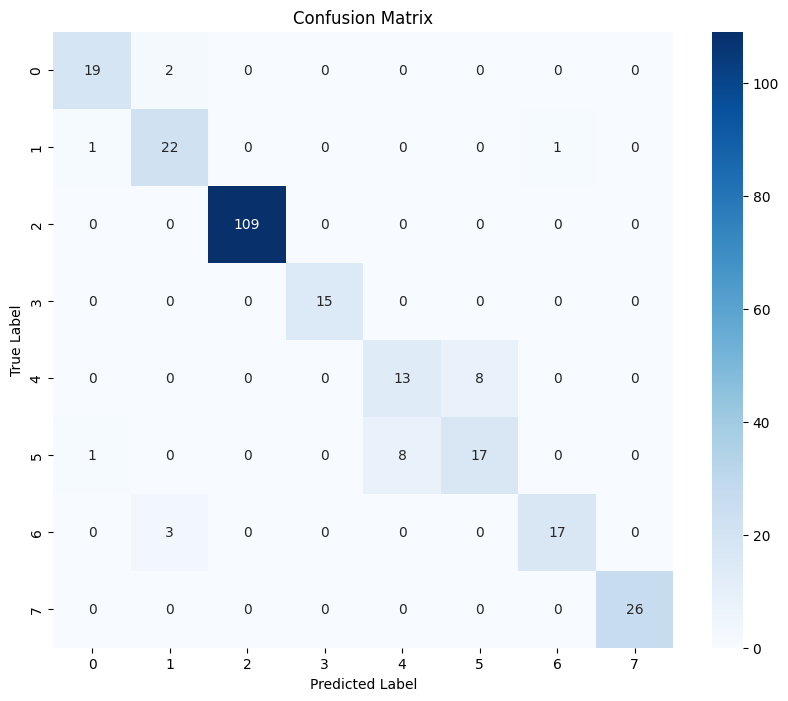

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions
pred = model.predict([X3_test, X2_test])

pred_labels = np.argmax(pred, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

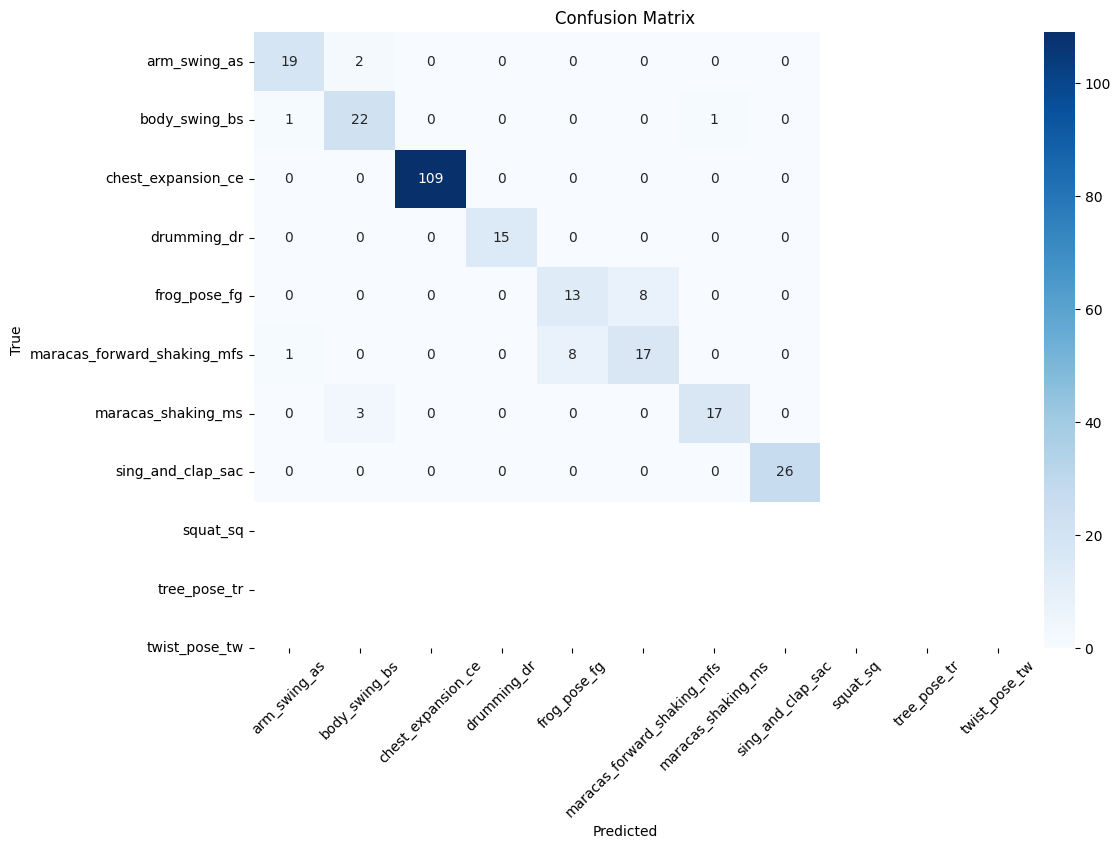

In [ ]:
class_names = le.classes_

plt.figure(figsize=(12,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

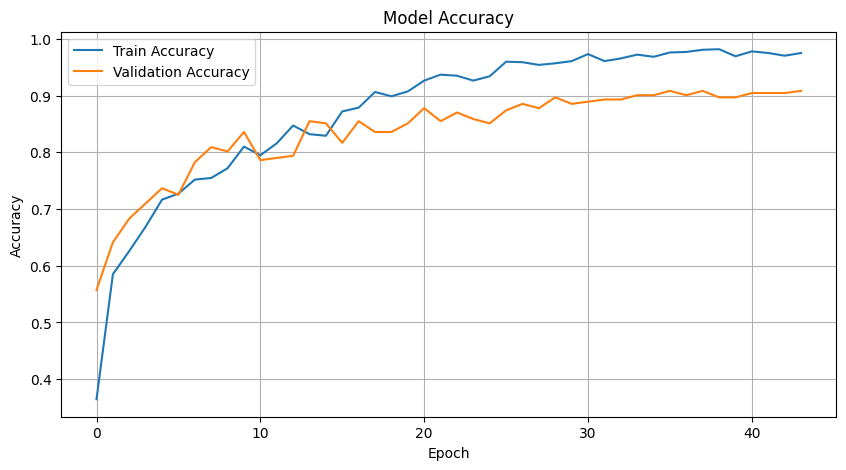

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

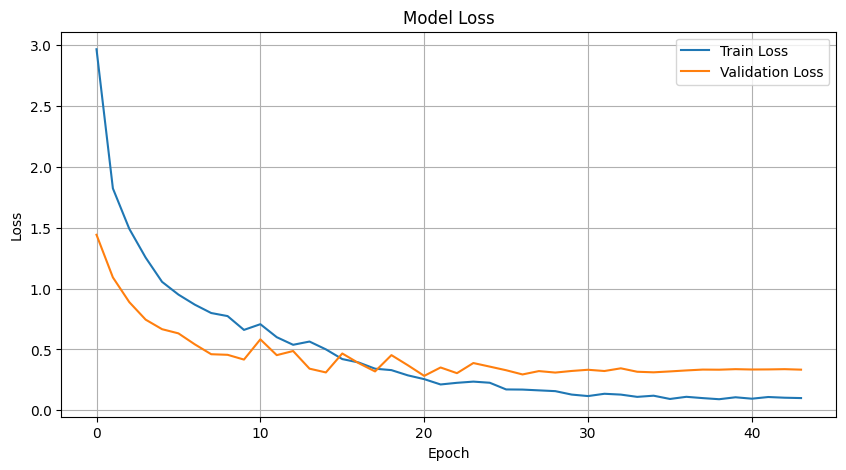

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

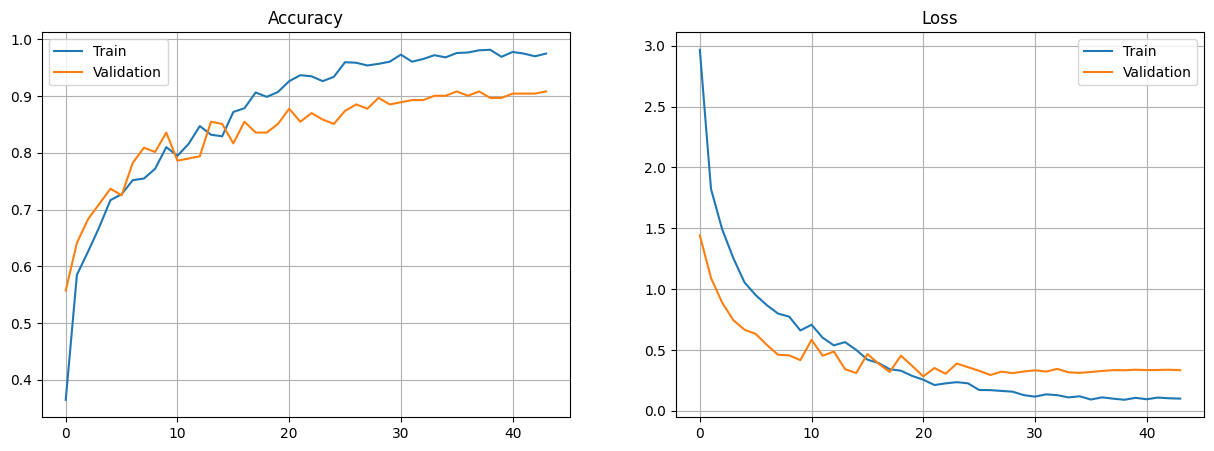

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

# Accuracy
ax[0].plot(history.history['accuracy'], label='Train')
ax[0].plot(history.history['val_accuracy'], label='Validation')
ax[0].set_title("Accuracy")
ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history.history['loss'], label='Train')
ax[1].plot(history.history['val_loss'], label='Validation')
ax[1].set_title("Loss")
ax[1].legend()
ax[1].grid(True)

plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import json

from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model


In [ ]:
def pad_or_trim(data, max_len=100):
    if len(data) > max_len:
        return data[:max_len]
    else:
        pad = np.zeros((max_len - len(data), data.shape[1]))
        return np.vstack((data, pad))

In [ ]:
X_3d = []
X_2d = []
X_flow = []
X_clinical = []
y = []

In [ ]:
for sequence_path in all_sequences:

    # -------- 3D Skeleton --------
    sk3d_file = os.path.join(sequence_path, "skeleton_3d.npz")
    sk3d = np.load(sk3d_file)['data']   # (T, 24, 3)
    sk3d = sk3d.reshape(sk3d.shape[0], -1)  # (T, 72)
    sk3d = pad_or_trim(sk3d)

    # -------- 2D Skeleton --------
    sk2d_file = os.path.join(sequence_path, "skeleton_2d.json")
    with open(sk2d_file) as f:
        sk2d = json.load(f)

    sk2d = np.array(sk2d)  # (T, 17, 2)
    sk2d = sk2d.reshape(sk2d.shape[0], -1)  # (T, 34)
    sk2d = pad_or_trim(sk2d)

    # -------- Optical Flow --------
    flow_file = os.path.join(sequence_path, "optical_flow.npy")
    flow = np.load(flow_file)  # (T-1, H, W)

    flow = flow.reshape(flow.shape[0], -1)  # flatten
    flow = pad_or_trim(flow)

    # -------- Clinical Data --------
    clinical_file = os.path.join(sequence_path, "clinical.csv")
    df = pd.read_csv(clinical_file)

    clinical = df[['motor_score', 'age', 'severity']].values[0]

    # -------- Label --------
    label = get_label(sequence_path)  # your existing function

    # -------- Append --------
    X_3d.append(sk3d)
    X_2d.append(sk2d)
    X_flow.append(flow)
    X_clinical.append(clinical)
    y.append(label)

NameError: name 'all_sequences' is not defined